<a href="https://colab.research.google.com/github/juanfelipegc016-maker/Machine-learning---Data-Analytics/blob/main/Machine_Learning_VENTAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller de Procesamiento de Datos - VENTAS_NL

## 0. Cargar librerías y el archivo



In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

 Importacion de librerías. pandas y numpy permiten trabajar y analizar los datos, mientras que matplotlib y seaborn se utilizan para generar gráficos. También se importan diferentes herramientas de Scikit-learn para realizar la imputación, estandarización, división de los datos y construcción del modelo de Machine Learning.

In [ ]:
candidatos = [
    Path("/content/VENTAS NL.xlsx"),
    Path("VENTAS NL.xlsx"),
    Path("upload/VENTAS NL.xlsx"),
]
ruta_archivo = next((p for p in candidatos if p.exists()), None)

if ruta_archivo is None:
    try:
        from google.colab import files
        cargados = files.upload()
        ruta_archivo = Path(next(iter(cargados)))
    except Exception as exc:
        raise FileNotFoundError(
            "Carga el archivo VENTAS NL.xlsx en la carpeta de trabajo."
        ) from exc

df_original = pd.read_excel(ruta_archivo)
print(f"Archivo cargado: {ruta_archivo}")
print(f"Dimensiones iniciales: {df_original.shape[0]:,} filas x {df_original.shape[1]} columnas")
display(df_original.head())

Saving VENTAS NL.xlsx to VENTAS NL.xlsx
Archivo cargado: VENTAS NL.xlsx
Dimensiones iniciales: 62,113 filas x 8 columnas


,id,EDAD,GENERO,SIZE,YEARINCOME,ventas,costo venta,DESCUENTOS
0,1000001,24,M,2,25100000.0,2.605867e+06,1.391244e+06,0.0374
1,1000002,26,M,5,118300000.0,1.152200e+05,6.200461e+04,0.0372
2,1000003,25,M,3,54500000.0,2.659438e+06,1.450845e+06,0.0328
3,1000004,26,H,3,194000000.0,5.780397e+06,2.720193e+06,0.0335
4,1000005,25,H,4,76000000.0,4.830493e+06,2.739421e+06,0.0475


En esta parte se busca y se carga el archivo de Excel con la información de ventas. Después se muestran las dimensiones iniciales de la base y las primeras filas para comprobar que los datos fueron cargados correctamente.

## 1. Limpieza y validación de datos

In [ ]:
df = df_original.copy()
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

Primero se crea una copia de la base original para trabajar sobre ella sin modificar los datos iniciales. También se estandarizan los nombres de las columnas, pasando todo a minúsculas y reemplazando.

In [ ]:
df["genero"] = df["genero"].astype("string").str.strip().str.upper()
columnas_numericas = [
    "id", "edad", "size", "yearincome", "ventas", "costo_venta", "descuentos"
]
for columna in columnas_numericas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

Se estandariza la variable género para que las categorías tengan un mismo formato. También se convierten las variables que deben ser numéricas a un formato numérico.

In [ ]:
filas_iniciales = len(df)
duplicados = int(df.duplicated().sum())
ids_duplicados = int(df.duplicated(subset="id").sum())
df = df.drop_duplicates().copy()

print(f"Filas iniciales: {filas_iniciales:,}")
print(f"Duplicados exactos eliminados: {duplicados}")
print(f"IDs repetidos detectados antes de eliminar: {ids_duplicados}")
print(f"Filas finales después de duplicados: {len(df):,}")

Filas iniciales: 62,113
Duplicados exactos eliminados: 15
IDs repetidos detectados antes de eliminar: 15
Filas finales después de duplicados: 62,098


Se identifican los registros que están completamente duplicados y también se revisan los identificadores repetidos. Después se eliminan los duplicados exactos para evitar que una misma observación tenga un peso mayor dentro del análisis.

Inicialmente se encontraron 15 registros duplicados, los cuales fueron eliminados para evitar que la misma información tuviera un peso mayor dentro del análisis. Después de este proceso, la base quedó con 62.098 registros.

In [ ]:
reglas_invalidas = {
    "id_no_unico": df["id"].duplicated(keep=False),
    "edad_fuera_0_120": df["edad"].notna() & ~df["edad"].between(0, 120),
    "genero_fuera_H_M": df["genero"].notna() & ~df["genero"].isin(["H", "M"]),
    "size_fuera_1_5": df["size"].notna() & ~df["size"].isin([1, 2, 3, 4, 5]),
    "yearincome_no_positivo": df["yearincome"].notna() & (df["yearincome"] <= 0),
    "ventas_no_positivas": df["ventas"].notna() & (df["ventas"] <= 0),
    "costo_no_positivo": df["costo_venta"].notna() & (df["costo_venta"] <= 0),
    "descuento_fuera_0_1": df["descuentos"].notna() & ~df["descuentos"].between(0, 1),
}
validacion = pd.DataFrame({
    "regla": reglas_invalidas.keys(),
    "registros_invalidos": [int(mascara.sum()) for mascara in reglas_invalidas.values()],
})
display(validacion)

,regla,registros_invalidos
0,id_no_unico,0
1,edad_fuera_0_120,0
2,genero_fuera_H_M,0
3,size_fuera_1_5,0
4,yearincome_no_positivo,0
5,ventas_no_positivas,0
6,costo_no_positivo,0
7,descuento_fuera_0_1,0


Se establecen reglas para verificar si existen valores que no cumplen con los rangos esperados. Se revisa la edad, el género, las tallas, los ingresos, las ventas, los costos y los descuentos. Esto permite identifcar psobles errores.

In [ ]:
df.loc[reglas_invalidas["edad_fuera_0_120"], "edad"] = np.nan
df.loc[reglas_invalidas["genero_fuera_H_M"], "genero"] = pd.NA
df.loc[reglas_invalidas["size_fuera_1_5"], "size"] = np.nan
df.loc[reglas_invalidas["yearincome_no_positivo"], "yearincome"] = np.nan
df.loc[reglas_invalidas["ventas_no_positivas"], "ventas"] = np.nan
df.loc[reglas_invalidas["costo_no_positivo"], "costo_venta"] = np.nan
df.loc[reglas_invalidas["descuento_fuera_0_1"], "descuentos"] = np.nan

print("Rangos observados después de validar:")
display(df[["edad", "size", "yearincome", "ventas", "costo_venta", "descuentos"]].agg(["min", "max"]))
print("Categorías de género:", df["genero"].value_counts(dropna=False).to_dict())

Rangos observados después de validar:


,edad,size,yearincome,ventas,costo_venta,descuentos
min,21.0,1.0,400000.0,26574.0,1.584000e+04,0.01
max,55.0,5.0,868900000.0,31999900.0,1.171547e+07,0.05


Categorías de género: {'M': 31065, 'H': 31033}


Se revisaron los rangos de las variables para identificar posibles valores que no fueran coherentes. La edad se encuentra entre 21 y 55 años, las tallas están entre 1 y 5 y los géneros corresponden a las categorías H y M, por lo que no se encontraron inconsistencias importantes.

### Datos faltantes, asimetría y método de imputación

Criterio usado:

- $|skewness| < 0.5$: distribución aproximadamente simétrica; la media es razonable.
- $|skewness| \geq 0.5$: distribución asimétrica; se prefiere la mediana.
- Si dos variables presentan una correlación muy alta y nunca faltan al mismo tiempo, puede justificarse una imputación por regresión.

In [ ]:
variables_con_faltantes = ["yearincome", "ventas", "costo_venta", "descuentos"]

resumen_faltantes = pd.DataFrame({
    "faltantes": df[variables_con_faltantes].isna().sum(),
    "porcentaje": df[variables_con_faltantes].isna().mean() * 100,
    "asimetria": df[variables_con_faltantes].skew(),
    "media": df[variables_con_faltantes].mean(),
    "mediana": df[variables_con_faltantes].median(),
}).round(4)

display(resumen_faltantes)

correlacion_ventas_costo = df[["ventas", "costo_venta"]].corr().iloc[0, 1]
ambas_faltantes = int((df["ventas"].isna() & df["costo_venta"].isna()).sum())
print(f"Correlación ventas-costo_venta: {correlacion_ventas_costo:.4f}")
print(f"Filas donde ambas variables faltan simultáneamente: {ambas_faltantes}")

,faltantes,porcentaje,asimetria,media,mediana
yearincome,1026,1.6522,1.2694,1.033027e+08,8.970000e+07
ventas,2528,4.0710,2.2650,3.412456e+06,2.441880e+06
costo_venta,1660,2.6732,2.3287,1.656939e+06,1.227749e+06
descuentos,1072,1.7263,-0.4145,3.320000e-02,3.480000e-02


Correlación ventas-costo_venta: 0.9789
Filas donde ambas variables faltan simultáneamente: 0


Se encontraron datos faltantes principalmente en las variables relacionadas con los ingresos, las ventas, el costo de venta y los descuentos. Por esta razón, antes de realizar la imputación se analizó la distribución de cada variable mediante el coeficiente de asimetría.

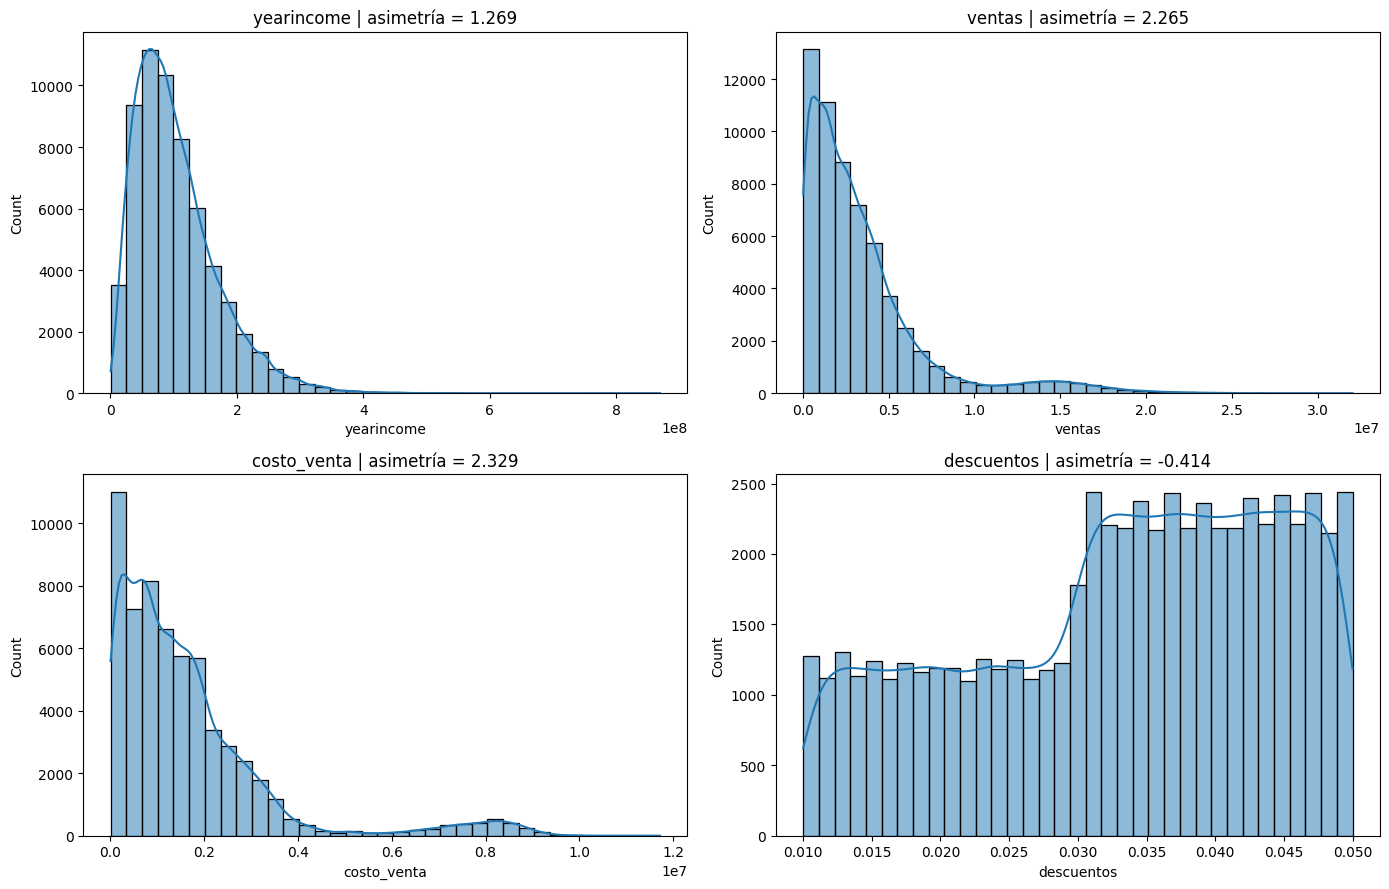

In [ ]:
fig, ejes = plt.subplots(2, 2, figsize=(14, 9))
for eje, columna in zip(ejes.ravel(), variables_con_faltantes):
    sns.histplot(df[columna].dropna(), bins=35, kde=True, ax=eje)
    eje.set_title(f"{columna} | asimetría = {df[columna].skew():.3f}")
plt.tight_layout()
plt.show()

Los gráficos permiten observar visualmente las diferencias en la distribución de las variables. En ventas y costo_venta se observa una mayor concentración de datos en valores bajos y una extensión hacia valores altos, lo que coincide con sus niveles elevados de asimetría.

### Decisión de imputación

En esta base se recomienda:

| Variable | Asimetría esperada | Método | Justificación |
|---|---:|---|---|
| `yearincome` | 1.269 | Mediana | Sesgo positivo alto; la mediana resiste ingresos extremos. |
| `ventas` | 2.265 | Regresión con `costo_venta` | Presenta sesgo alto, pero su correlación con el costo es 0.9789 y nunca faltan juntas. |
| `costo_venta` | 2.329 | Regresión con `ventas` | Misma relación fuerte; la regresión conserva mejor la relación comercial que una mediana fija. |
| `descuentos` | -0.414 | Media | Distribución aproximadamente simétrica, por lo que la media es representativa. |

Los resultados muestran que YEARINCOME, ventas y costo_venta presentan una asimetría positiva, mientras que descuentos tiene una distribución más cercana a simétrica. Estos resultados permiten seleccionar el método de imputación más adecuado para cada variable.

In [ ]:
# Conservar la versión previa a la imputación para evaluar el modelo sin fuga de datos
df_pre_imputacion = df.copy()

# Variables sin faltantes en la base original (estas líneas también cubren futuros valores inválidos)
df["edad"] = df["edad"].fillna(df["edad"].median())
df["size"] = df["size"].fillna(df["size"].mode().iloc[0])
df["genero"] = df["genero"].fillna(df["genero"].mode().iloc[0])

# YEARINCOME: mediana; DESCUENTOS: media
valor_yearincome = df["yearincome"].median()
valor_descuentos = df["descuentos"].mean()
df["yearincome"] = df["yearincome"].fillna(valor_yearincome)
df["descuentos"] = df["descuentos"].fillna(valor_descuentos)

# VENTAS y COSTO_VENTA: regresiones entrenadas solo con pares observados
pares_observados = df_pre_imputacion[["ventas", "costo_venta"]].dropna()

modelo_imputa_ventas = LinearRegression().fit(
    pares_observados[["costo_venta"]], pares_observados["ventas"]
)
mascara_ventas = df["ventas"].isna() & df["costo_venta"].notna()
df.loc[mascara_ventas, "ventas"] = modelo_imputa_ventas.predict(
    df.loc[mascara_ventas, ["costo_venta"]]
)

modelo_imputa_costo = LinearRegression().fit(
    pares_observados[["ventas"]], pares_observados["costo_venta"]
)
mascara_costo = df["costo_venta"].isna() & df["ventas"].notna()
df.loc[mascara_costo, "costo_venta"] = modelo_imputa_costo.predict(
    df.loc[mascara_costo, ["ventas"]]
)

# Protección ante predicciones numéricas imposibles
df["ventas"] = df["ventas"].clip(lower=0)
df["costo_venta"] = df["costo_venta"].clip(lower=0)

print(f"YEARINCOME imputado con mediana: ${valor_yearincome:,.0f}")
print(f"DESCUENTOS imputado con media: {valor_descuentos:.4%}")
print(f"VENTAS imputadas por regresión: {int(mascara_ventas.sum()):,}")
print(f"COSTOS imputados por regresión: {int(mascara_costo.sum()):,}")
print("Faltantes después de imputar:")
display(df.isna().sum().to_frame("faltantes"))

YEARINCOME imputado con mediana: $89,700,000
DESCUENTOS imputado con media: 3.3166%
VENTAS imputadas por regresión: 2,528
COSTOS imputados por regresión: 1,660
Faltantes después de imputar:


,faltantes
id,0
edad,0
genero,0
size,0
yearincome,0
ventas,0
costo_venta,0
descuentos,0


se muestran los valores utilizados para la imputación y la cantidad de registros que fueron completados mediante regresión. La última tabla permite comprobar que después del proceso ya no quedan datos faltantes en la base.


* YEARINCOME se decidió utilizar la mediana debido a su asimetría positiva.
* DESCUENTOS se utilizó la media porque su distribución es relativamente cercana a simétrica.
* ventas y costo_venta se utilizó una regresión, teniendo en cuenta la fuerte relación existente entre ambas variables.


Después de aplicar los métodos seleccionados, se completaron los valores faltantes de las variables analizadas. También se verificó nuevamente la base para comprobar que no quedaran valores nulos que pudieran afectar las siguientes etapas del procesamiento



## 2. Estandarización y normalización

In [ ]:
# Se conservan las variables originales y se crean columnas transformadas
standard_scaler = StandardScaler()
df[["yearincome_std", "ventas_std"]] = standard_scaler.fit_transform(
    df[["yearincome", "ventas"]]
)

minmax_scaler = MinMaxScaler()
df[["costo_venta_norm"]] = minmax_scaler.fit_transform(df[["costo_venta"]])

comprobacion_escalamiento = df[
    ["yearincome_std", "ventas_std", "costo_venta_norm"]
].agg(["mean", "std", "min", "max"])
display(comprobacion_escalamiento)

print("StandardScaler deja media cercana a 0 y desviación cercana a 1.")
print("MinMaxScaler deja costo_venta_norm entre 0 y 1.")

,yearincome_std,ventas_std,costo_venta_norm
mean,4.931623e-17,1.308997e-16,0.140346
std,1.000008e+00,1.000008e+00,0.148353
min,-1.584602e+00,-9.408446e-01,0.000000
max,1.181873e+01,7.945383e+00,1.000000


StandardScaler deja media cercana a 0 y desviación cercana a 1.
MinMaxScaler deja costo_venta_norm entre 0 y 1.


En esta etapa se aplicaron los métodos de escalamiento solicitados. YEARINCOME y ventas fueron estandarizadas con StandardScaler, mientras que costo_venta fue normalizado con MinMaxScaler para llevar sus valores a una escala entre 0 y 1.

Los resultados muestran que las variables transformadas con StandardScaler presentan una media cercana a 0 y una desviación estándar cercana a 1. Por otro lado, costo_venta_norm quedó dentro del rango entre 0 y 1, confirmando que los métodos de escalamiento fueron aplicados correctamente.

## 3. Ingeniería de características

In [ ]:
# 1) Ingreso realmente recibido después del descuento
df["ventas_netas"] = df["ventas"] * (1 - df["descuentos"])

# 2) Rentabilidad bruta después de descuento y costo
df["margen_bruto"] = df["ventas_netas"] - df["costo_venta"]

# 3) Margen relativo para comparar operaciones de tamaños diferentes
df["porcentaje_margen"] = np.where(
    df["ventas_netas"] != 0,
    df["margen_bruto"] / df["ventas_netas"],
    np.nan,
)

# 4) Segmentación de edad para análisis comercial
df["segmento_edad"] = pd.cut(
    df["edad"],
    bins=[0, 25, 35, 45, np.inf],
    labels=["21-25", "26-35", "36-45", "46+"],
    include_lowest=True,
)

display(df[[
    "ventas", "descuentos", "costo_venta", "ventas_netas",
    "margen_bruto", "porcentaje_margen", "edad", "segmento_edad"
]].head())


,ventas,descuentos,costo_venta,ventas_netas,margen_bruto,porcentaje_margen,edad,segmento_edad
0,2.605867e+06,0.0374,1.391244e+06,2.508407e+06,1.117164e+06,0.445368,24.0,21-25
1,1.152200e+05,0.0372,6.200461e+04,1.109338e+05,4.892921e+04,0.441067,26.0,26-35
2,2.659438e+06,0.0328,1.450845e+06,2.572209e+06,1.121364e+06,0.435954,25.0,21-25
3,5.780397e+06,0.0335,2.720193e+06,5.586754e+06,2.866561e+06,0.513099,26.0,26-35
4,4.830493e+06,0.0475,2.739421e+06,4.601045e+06,1.861624e+06,0.404609,25.0,21-25


En esta tabla se muestran las nuevas variables junto con algunos de los datos originales. De esta manera podemos comprobar cómo quedaron construidas las nuevas características.

In [ ]:
display(df.groupby("segmento_edad", observed=False)[
    ["ventas_netas", "margen_bruto"]
].mean().round(2))

,ventas_netas,margen_bruto
segmento_edad,,
21-25,3311220.10,1648687.53
26-35,3312287.16,1647398.54
36-45,3249960.86,1615199.47
46+,3339368.44,1653794.85


Se calcula el promedio de las ventas netas y del margen bruto para cada segmento de edad. Esto permite comparar el comportamiento comercial de los diferentes grupos de clientes.

### Justificación de las variables creadas

- **Ventas netas:** representa lo que realmente se recibe después del descuento; sirve para medir ingresos comerciales reales.
- **Margen bruto:** resta el costo a la venta neta; permite identificar ventas rentables o con pérdida.
- **Porcentaje de margen:** expresa la rentabilidad en proporción a la venta neta y permite comparar transacciones de montos diferentes.
- **Segmento de edad:** agrupa clientes en rangos interpretables para detectar patrones comerciales no lineales.

`ventas_netas`, `margen_bruto` y `porcentaje_margen` no se usan como predictores del costo porque contienen directamente el objetivo o información derivada de este.

## 4. Correlación y propuesta de modelo

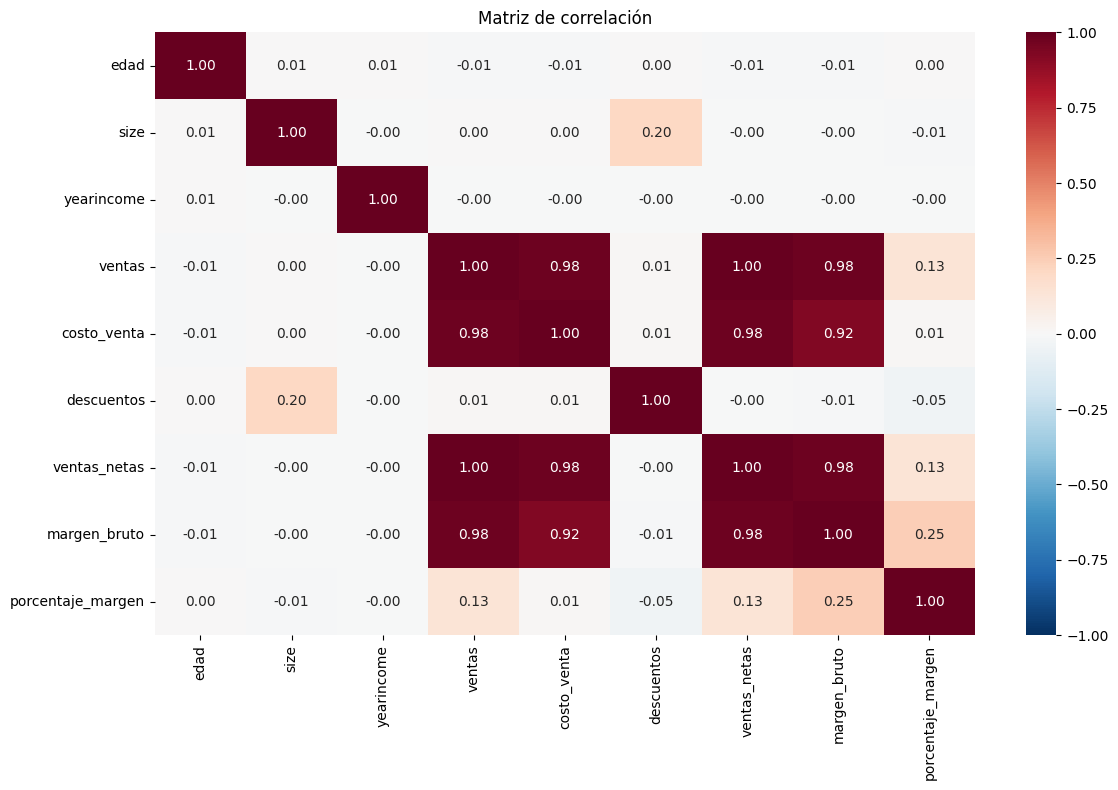

In [ ]:
columnas_correlacion = [
    "edad", "size", "yearincome", "ventas", "costo_venta", "descuentos",
    "ventas_netas", "margen_bruto", "porcentaje_margen"
]
matriz_correlacion = df[columnas_correlacion].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()


La matriz de correlación permite observar qué tan relacionadas están las variables numéricas entre sí. La relación más importante se encuentra entre ventas y costo_venta, ya que presentan una correlación muy alta, cercana a 0,98. Esto indica que ambas variables tienen un comportamiento muy relacionado dentro de la base.

In [ ]:
display(matriz_correlacion[["costo_venta"]].sort_values("costo_venta", ascending=False))

,costo_venta
costo_venta,1.000000
ventas,0.980221
ventas_netas,0.980133
margen_bruto,0.924502
descuentos,0.009222
porcentaje_margen,0.007890
size,0.002084
yearincome,-0.004080
edad,-0.008720


La correlación entre ventas y costo_venta es la más alta encontrada en el análisis. Esta relación resulta útil para plantear la predicción del costo de venta, aunque también es necesario tener cuidado con las variables que se utilizan para evitar incluir información que ya dependa directamente del objetivo.

### Propuesta de predicción

- **Objetivo:** `costo_venta`.
- **Momento de la predicción:** estimación provisional del costo cuando la venta ya fue registrada, pero el costo contable todavía no está disponible.
- **Predictoras disponibles en ese momento:** `ventas`, `edad`, `genero`, `size`, `yearincome` y `descuentos`.
- **Algoritmo:** `RandomForestRegressor`, porque permite relaciones no lineales, interacciones y no exige normalidad.
- **Prevención de fuga:** se excluyen `costo_venta_norm`, `margen_bruto` y `porcentaje_margen` porque incorporan el objetivo. También se evalúa únicamente con filas donde `ventas` y `costo_venta` eran originalmente observadas.

Si el objetivo fuera pronosticar ventas futuras antes de conocer la transacción, no podría usarse `costo_venta`; con las variables demográficas disponibles la evidencia preliminar es muy débil.

In [ ]:
# Solo observaciones reales de ventas y costo: no usar valores imputados para evaluar
df_modelo = df_pre_imputacion.loc[
    df_pre_imputacion["ventas"].notna()
    & df_pre_imputacion["costo_venta"].notna()
].copy()

predictoras = ["edad", "genero", "size", "yearincome", "ventas", "descuentos"]
objetivo = "costo_venta"

X = df_modelo[predictoras]
y = df_modelo[objetivo]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

predictoras_numericas = ["edad", "size", "yearincome", "ventas", "descuentos"]
predictoras_categoricas = ["genero"]

preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            Pipeline([
                ("imputador", SimpleImputer(strategy="median")),
                ("escalador", StandardScaler()),
            ]),
            predictoras_numericas,
        ),
        (
            "categoricas",
            Pipeline([
                ("imputador", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
            ]),
            predictoras_categoricas,
        ),
    ]
)

modelo = Pipeline([
    ("preprocesamiento", preprocesador),
    (
        "regresor",
        RandomForestRegressor(
            n_estimators=150,
            min_samples_leaf=5,
            max_features=1.0,
            random_state=42,
            n_jobs=-1,
        ),
    ),
])

modelo.fit(X_train, y_train)
predicciones = modelo.predict(X_test)

mae = mean_absolute_error(y_test, predicciones)
rmse = mean_squared_error(y_test, predicciones) ** 0.5
r2 = r2_score(y_test, predicciones)

# Línea base: predecir siempre la media del entrenamiento
base = DummyRegressor(strategy="mean")
base.fit(np.zeros((len(y_train), 1)), y_train)
pred_base = base.predict(np.zeros((len(y_test), 1)))
r2_base = r2_score(y_test, pred_base)

resultados_modelo = pd.DataFrame({
    "métrica": ["MAE", "RMSE", "R²", "R² línea base"],
    "valor": [mae, rmse, r2, r2_base],
})

print(f"Registros usados en el modelo: {len(df_modelo):,}")
display(resultados_modelo)
print(f"MAE: ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²: {r2:.4f}")

Registros usados en el modelo: 57,910


,métrica,valor
0,MAE,165436.999161
1,RMSE,296928.352202
2,R²,0.970121
3,R² línea base,-0.000061


MAE: $165,437
RMSE: $296,928
R²: 0.9701


El modelo obtuvo un buen desempeño en la prueba exploratoria, con un R² cercano a 0,97 y un MAE aproximado de $165.000. Esto indica que el modelo logra explicar gran parte de la variación del costo de venta y que, en promedio, el error de las predicciones se mantiene alrededor de ese valor.

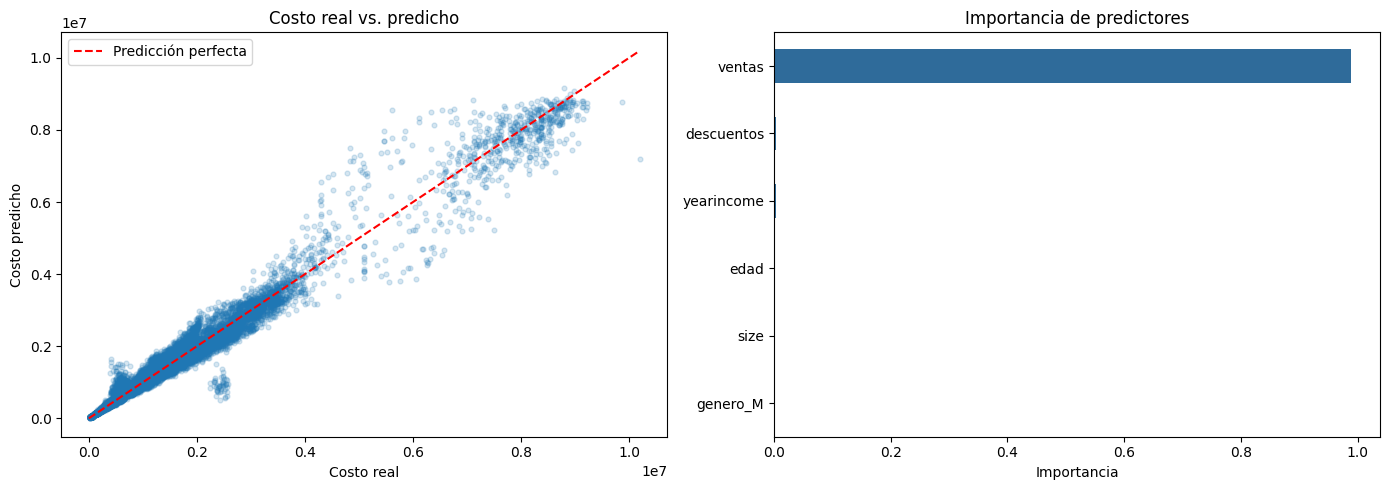

,importancia
ventas,0.988765
descuentos,0.003933
yearincome,0.003708
edad,0.002270
size,0.000858
genero_M,0.000465


In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Valores reales frente a predicciones
ejes[0].scatter(y_test, predicciones, alpha=0.18, s=12)
limite = max(float(y_test.max()), float(predicciones.max()))
ejes[0].plot([0, limite], [0, limite], "r--", label="Predicción perfecta")
ejes[0].set_xlabel("Costo real")
ejes[0].set_ylabel("Costo predicho")
ejes[0].set_title("Costo real vs. predicho")
ejes[0].legend()

# Importancia de variables
onehot = modelo.named_steps["preprocesamiento"].named_transformers_[
    "categoricas"
].named_steps["onehot"]
nombres_variables = predictoras_numericas + list(
    onehot.get_feature_names_out(predictoras_categoricas)
)
importancias = pd.Series(
    modelo.named_steps["regresor"].feature_importances_,
    index=nombres_variables,
).sort_values()
importancias.plot(kind="barh", ax=ejes[1], color="#2f6b9a")
ejes[1].set_title("Importancia de predictores")
ejes[1].set_xlabel("Importancia")

plt.tight_layout()
plt.show()
display(importancias.sort_values(ascending=False).to_frame("importancia"))

En el gráfico se puede observar que los valores predichos siguen de forma cercana el comportamiento de los valores reales. Mientras más cerca se encuentren los puntos de la línea de predicción perfecta, mejor es el comportamiento del modelo, por lo que el resultado obtenido muestra un ajuste favorable.


La importancia de las variables permite identificar cuáles tienen mayor influencia en las predicciones realizadas por el modelo. Esto ayuda a entender qué características de la información disponible tienen mayor relación con el costo de venta y cuáles tienen una menor participación.